In [1]:
from src.models import get_llm

In [2]:
model = get_llm()

### Conditional Workflow (Customer Support Intent Detection ChatBOT)
- Get user query
- Genrate a summary
- Classify as Intent Detected  
- Satisifed -> End
- Not Satisifed -> Ask for feedback
- Asking for Human -> Connect to Human Agent

In [7]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Annotated

In [9]:
from typing import Literal
from pydantic import BaseModel, Field


class ChatBotSchema(BaseModel):
    user_query: str = Field(description="The input query from the user.")

    summary: str = Field(description="A concise summary of the user's query.")

    intent: Literal[
        "satisfied",
        "not_satisfied",
        "connect_to_human",
    ] = Field(
        description=(
            "The intent classification. "
            "Must be one of: satisfied, not_satisfied, connect_to_human."
        )
    )

In [10]:
struct_llm = model.with_structured_output(schema=ChatBotSchema)

In [11]:
res = struct_llm.invoke(
    "I've already restarted my router three times, and the connection is still dropping. This didn't help."
)

In [13]:
main_system_prompt = """
You are an AI customer support assistant for a telephone service provider.

Your task is to analyze the user's latest message and produce a response that strictly conforms to the provided structured output schema.

## Instructions

1. Copy the user's original message exactly into the `user_query` field.
2. Generate a concise summary of the user's message in the `summary` field.
3. Classify the user's intent into **exactly one** of the following values:

   * `satisfied`
   * `not_satisfied`
   * `connect_to_human`

## Intent Definitions

### satisfied

Choose this when the user indicates that:

* Their issue has been resolved.
* They are happy with the assistance.
* They express gratitude or confirm everything is working.

Examples:

* "Thanks, my internet is working now."
* "That solved my problem."
* "Everything is fixed."

---

### not_satisfied

Choose this when the user indicates that:

* The issue still exists.
* The proposed solution did not work.
* They need additional troubleshooting.
* They are dissatisfied but have **not** explicitly requested a human agent.

Examples:

* "The problem is still there."
* "This didn't help."
* "My SIM still isn't activated."

---

### connect_to_human

Choose this when the user explicitly or strongly implies that they want to speak with a human customer service representative.

Examples:

* "Connect me to an agent."
* "I want to talk to customer support."
* "Transfer me to a human."
* "I don't want to chat with a bot anymore."

## Important Rules

* Return only information that matches the schema.
* The `intent` field must be exactly one of:

  * `satisfied`
  * `not_satisfied`
  * `connect_to_human`
* Do not invent information that the user did not provide.
* The summary should be factual, concise, and objective.
* Base the intent only on the user's latest message.
* If the user explicitly requests a human agent, always classify the intent as `connect_to_human`, even if the issue appears resolved.
* Never return values outside the allowed intent labels.

"""

In [17]:
main_system_prompt_template = ChatPromptTemplate.from_messages(
    [("system", main_system_prompt), ("human", "{query}")]
)

In [19]:
bot_chain = main_system_prompt_template | struct_llm

In [22]:
query = """
"I've already restarted my router three times, and the connection is still dropping. This didn't help."
"""
input_query = {"query": query}

In [23]:
res = bot_chain.invoke(input_query)

### Defining State

In [26]:
from typing import TypedDict

In [31]:
class ChatBotState(TypedDict):
    query: str
    summary: str
    intent: str
    action: str

### Nodes Definiton

In [ ]:
def not_satisfied(state: ChatBotState):
    action = (
        "Sorry for the inconvience. Kindly Mail us to 123@gmail.com for any feedbacks"
    )
    return {"action": action}

In [36]:
def satisfied(state: ChatBotState):
    action = "Glad we could help"
    return {"action": action}

In [37]:
def connect(state: ChatBotState):
    action = "Connected to Human based on user request"
    return {"action": action}

In [60]:
def get_intent(state: ChatBotState):
    query = state["query"]
    results = bot_chain.invoke({"query": query})
    user_intent = results.intent
    summary = results.summary
    return {"intent": user_intent, "summary": summary}

In [61]:
# Aggregtor should return node name to be exceuted
def check_intent(
    state: ChatBotState,
) -> Literal["not_satisfied", "satisfied", "connect"]:
    user_intent = state["intent"]
    if user_intent == "not_satisfied":
        return "not_satisfied"
    elif user_intent == "satisfied":
        return "satisfied"
    else:
        return "connect"

### Graph

In [62]:
from langgraph.graph import StateGraph

In [63]:
graph = StateGraph(state_schema=ChatBotState)

### Creating Nodes

In [64]:
graph.add_node("get_intent", get_intent)
graph.add_node("not_satisfied", not_satisfied)
graph.add_node("satisfied", satisfied)
graph.add_node("connect", connect)

### Creating Edges

In [65]:
from langgraph.graph import START, END

In [66]:
graph.add_edge(START, "get_intent")
graph.add_conditional_edges("get_intent", check_intent)
graph.add_edge("connect", END)
graph.add_edge("satisfied", END)
graph.add_edge("not_satisfied", END)

In [67]:
workflow = graph.compile()

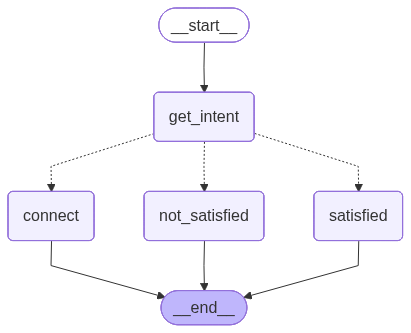

In [68]:
workflow

In [87]:
query = """Ive had enough. Let me speak to someone."""

In [88]:
intial_state = {"query": query.strip()}

In [89]:
final_state = workflow.invoke(intial_state)

In [90]:
final_state

{'query': 'Ive had enough. Let me speak to someone.',
 'summary': 'User wants to speak to a human customer service representative',
 'intent': 'connect_to_human',
 'action': 'Connected to Human based on user request'}